<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/MLLab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coefficient (slope): 0.00966391609242183
Intercept: 0.07809818806957772

First 5 actual y values:
0    0.752539
1    0.000000
2    0.000000
3    0.000000
4    0.000000
Name: Feature_4010, dtype: float64

First 5 predicted y values:
[0.08813488 0.08856939 0.07809819 0.07809819 0.07809819]
TRAIN SET METRICS
MSE : 0.19243802970866586
RMSE: 0.43867759198375506
MAPE: inf
R2  : 0.0006996092190540981

 TEST SET METRICS
MSE : 0.05882997839648842
RMSE: 0.24254891959456018
MAPE: inf
R2  : -0.04199909006862912
TRAIN SET METRICS
MSE : 2.32516357284908e-30
RMSE: 1.524848704904549e-15
MAPE: inf
R2  : 1.0

TEST SET METRICS
MSE : 0.04128788771126754
RMSE: 0.2031942118055225
MAPE: inf
R2  : 0.2687071693950426
Cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

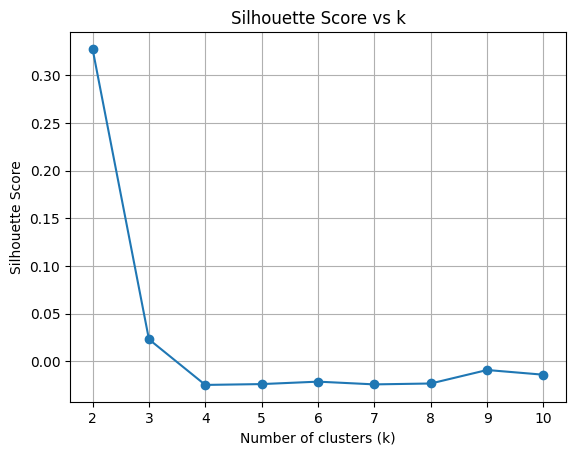

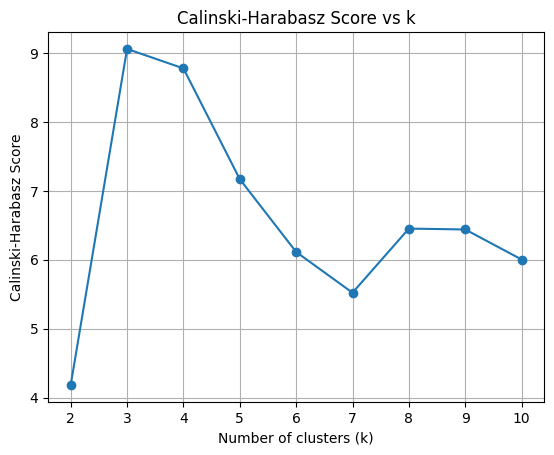

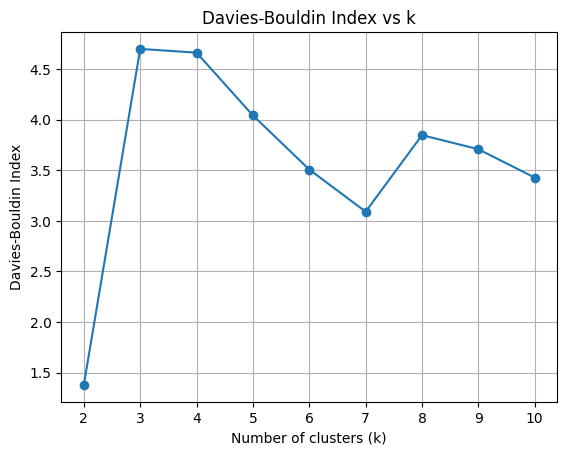

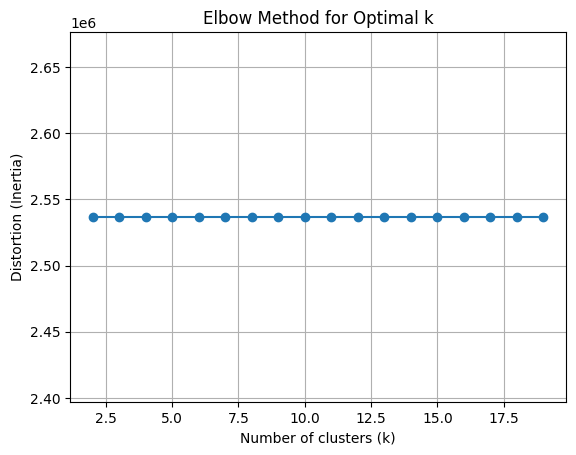

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
#optional scaling
from sklearn.preprocessing import StandardScaler

#extract features
df = pd.read_excel("/content/Stereotype ml dataset.xlsx", engine="openpyxl")
features = df.drop(columns=["Label"])
features = features.select_dtypes(include=["int64", "float64"])


#A1
X_train = df[["Feature_4006"]]   # X must be 2D
y_train = df["Feature_4010"]  # y must be 1D

def linear_regression(X, y):
    """Performs linear regression and returns model and predictions"""
    reg = LinearRegression()
    reg.fit(X, y)
    y_pred = reg.predict(X)
    return reg, y_pred

reg, y_train_pred = linear_regression(X_train, y_train)

print("Coefficient (slope):", reg.coef_[0])
print("Intercept:", reg.intercept_)
print("\nFirst 5 actual y values:")
print(y_train.head())
print("\nFirst 5 predicted y values:")
print(y_train_pred[:5])

#A2
X = df[["Feature_4006"]]     # 1 feature, 2D
y = df["Feature_4010"]       # numerical target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

def regression_metrics(y_true, y_pred):
    """ Calculates MSE, RMSE, MAPE, and R2 score """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mape, r2

train_mse, train_rmse, train_mape, train_r2 = regression_metrics(y_train, y_train_pred)
test_mse, test_rmse, test_mape, test_r2 = regression_metrics(y_test, y_test_pred)

print("TRAIN SET METRICS")
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("MAPE:", train_mape)
print("R2  :", train_r2)

print("\n TEST SET METRICS")
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)
print("R2  :", test_r2)


#A3
# Use ALL numerical features except the chosen target
X = df.drop(columns=["Feature_4010", "Label"], errors="ignore")
X = X.select_dtypes(include=["int64", "float64"])

y = df["Feature_4010"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg, y_train_pred = linear_regression(X_train, y_train)
y_test_pred = reg.predict(X_test)
train_mse, train_rmse, train_mape, train_r2 = regression_metrics(y_train, y_train_pred)

test_mse, test_rmse, test_mape, test_r2 = regression_metrics(y_test, y_test_pred)

print("TRAIN SET METRICS")
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("MAPE:", train_mape)
print("R2  :", train_r2)

print("\nTEST SET METRICS")
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)
print("R2  :", test_r2)



X = features.values
#or X = df.drop("Label")
y = df["Label"].values  # target (NOT used in clustering)
#A4

#Feature scaling (VERY IMPORTANT for K-means)
def scale_features(X):
    """
    Scales the feature matrix using StandardScaler
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


#Apply K-means clustering

def apply_kmeans(X_scaled, n_clusters=2, random_state=0):
    """
    Applies K-means clustering
    """
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init="auto"
    )
    kmeans.fit(X_scaled)
    return kmeans


# Feature scaling
X_scaled = scale_features(X)

# Apply K-means clustering
kmeans = apply_kmeans(X_scaled, n_clusters=2, random_state=0)

# Cluster labels
cluster_labels = kmeans.labels_
print("Cluster labels:")
print(cluster_labels)

# Cluster centers
cluster_centers = kmeans.cluster_centers_
print("Cluster centers:")
print(cluster_centers)


#A5


def evaluate_clustering(X_scaled, labels):
    """Computes Silhouette, CH, and DB scores"""

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    return sil, ch, db

sil_score, ch_score, db_score = evaluate_clustering(X_scaled,kmeans.labels_)
print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)
print("Davies-Bouldin Index:", db_score)



#A6
# ploting for wide values of k
def plot_scores(k_values, sil_scores, ch_scores, db_scores):
    # Silhouette Score
    plt.figure()
    plt.plot(k_values, sil_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score vs k")
    plt.grid(True)
    plt.show()

    # Calinski–Harabasz Score
    plt.figure()
    plt.plot(k_values, ch_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Calinski-Harabasz Score")
    plt.title("Calinski-Harabasz Score vs k")
    plt.grid(True)
    plt.show()

    # Davies–Bouldin Index
    plt.figure()
    plt.plot(k_values, db_scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Davies-Bouldin Index")
    plt.title("Davies-Bouldin Index vs k")
    plt.grid(True)
    plt.show()


# Scale features
X_scaled = scale_features(X)

# Range of k values
k_values = range(2, 11)

silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_values:
    kmeans = apply_kmeans(X_scaled, n_clusters=k)
    sil, ch, db = evaluate_clustering(X_scaled, kmeans.labels_)

    silhouette_scores.append(sil)
    ch_scores.append(ch)
    db_scores.append(db)

plot_scores(k_values, silhouette_scores, ch_scores, db_scores)


#A7
# finding optimal k value using elbow mwthod
def elbow_method(X_scaled, k_range=range(2, 20)):
    """Computes distortions (inertia) for different k values"""
    distortions = []

    for k in k_range:
        kmeans = apply_kmeans(X_scaled, n_clusters=2, random_state=0)
        distortions.append(kmeans.inertia_)

    return distortions

def plot_elbow(k_values, distortions):
    plt.figure()
    plt.plot(k_values, distortions, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Distortion (Inertia)")
    plt.title("Elbow Method for Optimal k")
    plt.grid(True)
    plt.show()


k_values = range(2, 20)
distortions = elbow_method(X_scaled, k_values)
plot_elbow(k_values, distortions)
